<a href="https://colab.research.google.com/github/budennovsk/testovoe_Media_108/blob/budennovsk%2Fpythonanywere/testovoe_108.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [107]:
!pip install catboost
!pip install category_encoders

In [108]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, roc_curve, precision_recall_curve
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import seaborn as sns




In [109]:
# Загружаем файл
file_path = '/content/drive/MyDrive/Colab Notebooks/zvezda/Server_zvezda/Dataset/logs_api_test.tsv'
# Загружаем файл с разделителем табуляции
df = pd.read_csv(file_path, sep='\t',low_memory=False)

# Просмотрим первые несколько строк





In [110]:
df['ym:s:goalsID']

,ym:s:goalsID
0,[]
1,[]
2,[]
3,[]
4,[]
...,...
13599,[]
13600,[]
13601,[]
13602,[291725831]


In [111]:

# Рассчитываем количество NaN в каждой колонке
nan_count = df.isna().sum()

# Рассчитываем процент пропусков для каждой колонки
nan_percentage = nan_count / len(df) * 100

# Выводим колонки с более чем 30% пропусков и сортируем по убыванию
columns_with_nan_above_30 = nan_percentage[nan_percentage > 30].sort_values(ascending=False)
print(columns_with_nan_above_30)


ym:s:firstopenstatSource                              100.000000
ym:s:automaticopenstatService                         100.000000
ym:s:cross_device_lastClickBannerGroupName            100.000000
ym:s:lastopenstatAd                                   100.000000
ym:s:lastsignopenstatAd                               100.000000
                                                         ...    
ym:s:cross_device_firstSearchEngine                    33.644516
ym:s:lastsignSearchEngine                              33.593061
ym:s:lastsignSearchEngineRoot                          33.593061
ym:s:cross_device_last_significantSearchEngineRoot     33.578359
ym:s:cross_device_last_significantSearchEngine         33.578359
Length: 201, dtype: float64


In [112]:
df['ym:s:cross_device_lastopenstatSource'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 13604 entries, 0 to 13603
Series name: ym:s:cross_device_lastopenstatSource
Non-Null Count  Dtype  
--------------  -----  
0 non-null      float64
dtypes: float64(1)
memory usage: 106.4 KB


In [113]:
# Рассчитываем количество NaN в каждой колонке
nan_count = df.isna().sum()

# Рассчитываем процент пропусков для каждой колонки
nan_percentage = nan_count / len(df) * 100

# Выводим колонки с более чем 5% пропусков
columns_with_nan_above_5 = nan_percentage[nan_percentage > 5]
print(columns_with_nan_above_5)

ym:s:networkType                  71.339312
ym:s:regionCity                   21.229050
ym:s:automaticReferalSource       91.943546
ym:s:automaticSearchEngine        34.056160
ym:s:automaticSearchEngineRoot    34.056160
                                    ...    
ym:s:lastGCLID                    99.992649
ym:s:lastsignGCLID                99.992649
ym:s:mobilePhone                  48.706263
ym:s:mobilePhoneModel             46.905322
ym:s:referer                      19.273743
Length: 205, dtype: float64


In [114]:
# Находим колонки с более чем 30% пропусков
columns_to_drop = nan_percentage[nan_percentage > 30].index

# Удаляем эти колонки из DataFrame
df_cleaned = df.drop(columns=columns_to_drop)

# Выводим очищенный DataFrame (или можно сохранить его в файл)
df_cleaned

,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:bounce,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,...,ym:s:productsPrice,ym:s:productsQuantity,ym:s:productsVariant,ym:s:promotionCreative,ym:s:promotionCreativeSlot,ym:s:promotionEventTime,ym:s:promotionID,ym:s:promotionName,ym:s:promotionPosition,ym:s:promotionType
0,ya_undefined,organic,0,11416242040820647116,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]
1,ya_undefined,social,0,8986770264062708149,ya_undefined,social,ya_undefined,social,ya_undefined,social,...,[],[],[],[],[],[],[],[],[],[]
2,ya_undefined,organic,0,1560789870665284591,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]
3,ya_undefined,organic,1,5475665434488658611,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]
4,ya_undefined,referral,0,13320641695455499232,ya_undefined,referral,ya_undefined,referral,ya_undefined,referral,...,[],[],[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,ya_undefined,organic,0,8255078945470868180,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]
13600,ya_undefined,organic,1,17957706397172160869,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]
13601,ya_undefined,organic,0,14326908916227954062,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]
13602,ya_undefined,organic,0,3102893020254001707,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],[],[],[],[],[],[]


In [115]:

# 1. Рассчитываем процент нулевых значений в каждой колонке
zero_percentage = (df_cleaned == 0).mean() * 100

# 2. Фильтруем колонки, где процент нулевых значений больше 30%
columns_with_high_zeros = zero_percentage[zero_percentage > 30]

# 3. Сортируем по убыванию
columns_with_high_zeros_sorted = columns_with_high_zeros.sort_values(ascending=False)

# 4. Выводим результаты
print(columns_with_high_zeros_sorted)
print(len(columns_with_high_zeros_sorted))

ym:s:cross_device_lastDirectBannerGroup                            100.000000
ym:s:browserEngineVersion4                                         100.000000
ym:s:lastDirectClickBanner                                         100.000000
ym:s:lastDirectBannerGroup                                         100.000000
ym:s:cross_device_lastDirectClickBannerName                        100.000000
ym:s:lastDirectClickBannerName                                     100.000000
ym:s:cross_device_lastDirectClickOrderName                         100.000000
ym:s:cross_device_lastDirectClickBanner                            100.000000
ym:s:lastDirectClickOrderName                                      100.000000
ym:s:automatichasGCLID                                              99.992649
ym:s:cross_device_last_significanthasGCLID                          99.992649
ym:s:cross_device_last_yandex_direct_clickhasGCLID                  99.992649
ym:s:cross_device_lasthasGCLID                                  

In [116]:
# 1. Рассчитываем процент нулевых значений в каждой колонке
zero_percentage = (df_cleaned == 0).mean() * 100

# 2. Фильтруем колонки, где процент нулевых значений больше 30%
columns_with_high_zeros = zero_percentage[zero_percentage > 30].index.tolist()

# 3. Удаляем эти колонки из DataFrame
df_cleaned_dropped = df_cleaned.drop(columns=columns_with_high_zeros)

# 4. Выводим, какие колонки были удалены
print(f"Удаленные колонки: {columns_with_high_zeros}")


Удаленные колонки: ['ym:s:bounce', 'ym:s:automaticDirectBannerGroup', 'ym:s:automaticDirectClickBanner', 'ym:s:cross_device_firstDirectBannerGroup', 'ym:s:cross_device_firstDirectClickBanner', 'ym:s:cross_device_last_significantDirectBannerGroup', 'ym:s:cross_device_last_significantDirectClickBanner', 'ym:s:cross_device_last_yandex_direct_clickDirectBannerGroup', 'ym:s:cross_device_last_yandex_direct_clickDirectClickBanner', 'ym:s:cross_device_lastDirectBannerGroup', 'ym:s:cross_device_lastDirectClickBanner', 'ym:s:cross_device_lastDirectClickOrderName', 'ym:s:firstDirectBannerGroup', 'ym:s:firstDirectClickBanner', 'ym:s:last_yandex_direct_clickDirectBannerGroup', 'ym:s:last_yandex_direct_clickDirectClickBanner', 'ym:s:lastDirectBannerGroup', 'ym:s:lastDirectClickBanner', 'ym:s:lastDirectClickOrderName', 'ym:s:lastsignDirectBannerGroup', 'ym:s:lastsignDirectClickBanner', 'ym:s:automaticDirectClickBannerName', 'ym:s:cross_device_firstDirectClickBannerName', 'ym:s:cross_device_last_signi

In [117]:
df_cleaned_dropped

,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,ym:s:cross_device_lastAdvEngine,...,ym:s:productsPrice,ym:s:productsQuantity,ym:s:productsVariant,ym:s:promotionCreative,ym:s:promotionCreativeSlot,ym:s:promotionEventTime,ym:s:promotionID,ym:s:promotionName,ym:s:promotionPosition,ym:s:promotionType
0,ya_undefined,organic,11416242040820647116,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
1,ya_undefined,social,8986770264062708149,ya_undefined,social,ya_undefined,social,ya_undefined,social,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
2,ya_undefined,organic,1560789870665284591,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
3,ya_undefined,organic,5475665434488658611,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
4,ya_undefined,referral,13320641695455499232,ya_undefined,referral,ya_undefined,referral,ya_undefined,referral,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,ya_undefined,organic,8255078945470868180,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
13600,ya_undefined,organic,17957706397172160869,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
13601,ya_undefined,organic,14326908916227954062,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]
13602,ya_undefined,organic,3102893020254001707,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,ya_undefined,...,[],[],[],[],[],[],[],[],[],[]


In [118]:
# 1. Преобразуем столбцы, содержащие строки с пустыми списками, в булевы значения
empty_lists = df_cleaned.apply(lambda col: col == '[]').mean() * 100

# 2. Фильтруем колонки, где процент строк с пустыми списками больше 95%
columns_with_more_than_95_percent_empty_lists = empty_lists[empty_lists > 95]

# 3. Сортируем по убыванию
columns_sorted_by_empty_lists = columns_with_more_than_95_percent_empty_lists.sort_values(ascending=False)

# 4. Выводим результат
print(columns_sorted_by_empty_lists)


ym:s:eventsProductBrand             100.000000
ym:s:impressionsProductCategory5    100.000000
ym:s:productsCategory3              100.000000
ym:s:productsCategory2              100.000000
ym:s:productsCategory1              100.000000
                                       ...    
ym:s:parsedParamsKey4                99.272273
ym:s:parsedParamsKey5                99.272273
ym:s:parsedParamsKey6                99.272273
ym:s:parsedParamsKey7                99.272273
ym:s:parsedParamsKey8                99.272273
Length: 83, dtype: float64


In [119]:
# 1. Преобразуем столбцы, содержащие строки с пустыми списками, в булевы значения
empty_lists = df_cleaned.apply(lambda col: col == '[]').mean() * 100

# 2. Фильтруем колонки, где процент строк с пустыми списками больше 98%
columns_with_more_than_98_percent_empty_lists = empty_lists[empty_lists > 98].index.tolist()

# 3. Удаляем эти колонки из DataFrame
df_cleaned_dropped = df_cleaned.drop(columns=columns_with_more_than_98_percent_empty_lists)

# 4. Выводим список удалённых колонок
print(f"Удаленные колонки: {columns_with_more_than_98_percent_empty_lists}")


Удаленные колонки: ['ym:s:eventsProductBrand', 'ym:s:eventsProductCategory', 'ym:s:eventsProductCategory1', 'ym:s:eventsProductCategory2', 'ym:s:eventsProductCategory3', 'ym:s:eventsProductCategory4', 'ym:s:eventsProductCategory5', 'ym:s:eventsProductCoupon', 'ym:s:eventsProductCurrency', 'ym:s:eventsProductDiscount', 'ym:s:eventsProductEventTime', 'ym:s:eventsProductID', 'ym:s:eventsProductList', 'ym:s:eventsProductName', 'ym:s:eventsProductPosition', 'ym:s:eventsProductPrice', 'ym:s:eventsProductQuantity', 'ym:s:eventsProductType', 'ym:s:eventsProductVariant', 'ym:s:productsID', 'ym:s:productsPurchaseID', 'ym:s:purchaseAffiliation', 'ym:s:purchaseCoupon', 'ym:s:purchaseCurrency', 'ym:s:purchaseDateTime', 'ym:s:purchaseID', 'ym:s:purchaseProductQuantity', 'ym:s:purchaseRevenue', 'ym:s:purchaseShipping', 'ym:s:purchaseTax', 'ym:s:impressionsDateTime', 'ym:s:impressionsProductBrand', 'ym:s:impressionsProductCategory', 'ym:s:impressionsProductCategory1', 'ym:s:impressionsProductCategory2

In [120]:
df_cleaned_dropped

,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:bounce,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,...,ym:s:screenOrientation,ym:s:screenWidth,ym:s:windowClientHeight,ym:s:windowClientWidth,ym:s:offlineCallFirstTimeCaller,ym:s:offlineCallHoldDuration,ym:s:offlineCallMissed,ym:s:offlineCallTag,ym:s:offlineCallTalkDuration,ym:s:offlineCallURL
0,ya_undefined,organic,0,11416242040820647116,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,390,663,390,[],[],[],[],[],[]
1,ya_undefined,social,0,8986770264062708149,ya_undefined,social,ya_undefined,social,ya_undefined,social,...,1,360,729,360,[],[],[],[],[],[]
2,ya_undefined,organic,0,1560789870665284591,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,393,720,393,[],[],[],[],[],[]
3,ya_undefined,organic,1,5475665434488658611,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,2,1920,929,1903,[],[],[],[],[],[]
4,ya_undefined,referral,0,13320641695455499232,ya_undefined,referral,ya_undefined,referral,ya_undefined,referral,...,1,407,827,407,[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,ya_undefined,organic,0,8255078945470868180,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,2,1470,832,1470,[],[],[],[],[],[]
13600,ya_undefined,organic,1,17957706397172160869,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,393,733,393,[],[],[],[],[],[]
13601,ya_undefined,organic,0,14326908916227954062,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,360,657,360,[],[],[],[],[],[]
13602,ya_undefined,organic,0,3102893020254001707,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,360,745,360,[-1],[0],[0],[''],[0],['']


In [121]:
df_cleaned_dropped['ym:s:goalsID'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 13604 entries, 0 to 13603
Series name: ym:s:goalsID
Non-Null Count  Dtype 
--------------  ----- 
13604 non-null  object
dtypes: object(1)
memory usage: 106.4+ KB


In [122]:


# 1. Извлекаем числовые столбцы, игнорируя столбцы с типом 'object'
numeric_columns = df_cleaned_dropped.select_dtypes(include=['number']).columns.tolist()

# 2. Создаем новый DataFrame, включающий только числовые колонки
df_numeric = df_cleaned_dropped[numeric_columns]

# 3. Заменяем Inf и -Inf на NaN
df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)

# 4. Удаляем строки с NaN
df_numeric.dropna(axis=0, inplace=True)

# 5. Добавляем столбец единиц для расчета VIF
df_numeric_with_const = add_constant(df_numeric)

# 6. Функция для расчета VIF
def calculate_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    return vif_data

# 7. Рассчитываем VIF для всех числовых признаков
vif_df = calculate_vif(df_numeric_with_const)

# 8. Фильтруем признаки с VIF > 10 (или другим порогом)
high_vif_features = vif_df[vif_df["VIF"] > 10]["feature"].tolist()

# 9. Удаляем признаки с высоким VIF
df_cleaned_reduced_vif = df_cleaned_dropped.drop(columns=high_vif_features)

# 10. Выводим список удаленных признаков
print(f"Удаленные признаки с VIF > 10: {high_vif_features}")
print(len(high_vif_features))


<ipython-input-122-593f02118ff6>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric.replace([np.inf, -np.inf], np.nan, inplace=True)
<ipython-input-122-593f02118ff6>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_numeric.dropna(axis=0, inplace=True)
/usr/local/lib/python3.11/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: invalid value encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.11/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


Удаленные признаки с VIF > 10: ['ym:s:automaticDirectBannerGroup', 'ym:s:automaticDirectClickBanner', 'ym:s:cross_device_firstDirectBannerGroup', 'ym:s:cross_device_firstDirectClickBanner', 'ym:s:cross_device_last_significantDirectBannerGroup', 'ym:s:cross_device_last_significantDirectClickBanner', 'ym:s:cross_device_last_yandex_direct_clickDirectBannerGroup', 'ym:s:cross_device_last_yandex_direct_clickDirectClickBanner', 'ym:s:firstDirectBannerGroup', 'ym:s:firstDirectClickBanner', 'ym:s:last_yandex_direct_clickDirectBannerGroup', 'ym:s:last_yandex_direct_clickDirectClickBanner', 'ym:s:lastsignDirectBannerGroup', 'ym:s:lastsignDirectClickBanner', 'ym:s:automaticDirectClickBannerName', 'ym:s:cross_device_firstDirectClickBannerName', 'ym:s:cross_device_last_significantDirectClickBannerName', 'ym:s:cross_device_last_yandex_direct_clickDirectClickBannerName', 'ym:s:firstDirectClickBannerName', 'ym:s:last_yandex_direct_clickDirectClickBannerName', 'ym:s:lastsignDirectClickBannerName']
21


In [123]:
df_cleaned_reduced_vif

,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:bounce,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,...,ym:s:screenOrientation,ym:s:screenWidth,ym:s:windowClientHeight,ym:s:windowClientWidth,ym:s:offlineCallFirstTimeCaller,ym:s:offlineCallHoldDuration,ym:s:offlineCallMissed,ym:s:offlineCallTag,ym:s:offlineCallTalkDuration,ym:s:offlineCallURL
0,ya_undefined,organic,0,11416242040820647116,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,390,663,390,[],[],[],[],[],[]
1,ya_undefined,social,0,8986770264062708149,ya_undefined,social,ya_undefined,social,ya_undefined,social,...,1,360,729,360,[],[],[],[],[],[]
2,ya_undefined,organic,0,1560789870665284591,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,393,720,393,[],[],[],[],[],[]
3,ya_undefined,organic,1,5475665434488658611,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,2,1920,929,1903,[],[],[],[],[],[]
4,ya_undefined,referral,0,13320641695455499232,ya_undefined,referral,ya_undefined,referral,ya_undefined,referral,...,1,407,827,407,[],[],[],[],[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,ya_undefined,organic,0,8255078945470868180,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,2,1470,832,1470,[],[],[],[],[],[]
13600,ya_undefined,organic,1,17957706397172160869,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,393,733,393,[],[],[],[],[],[]
13601,ya_undefined,organic,0,14326908916227954062,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,360,657,360,[],[],[],[],[],[]
13602,ya_undefined,organic,0,3102893020254001707,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,360,745,360,[-1],[0],[0],[''],[0],['']


In [124]:
df_cleaned_reduced_vif.head(1000).to_excel('2.xlsx')

In [125]:

# Преобразуем каждый элемент строки в список и извлекаем уникальные числа
unique_ints = set()

for item in df_cleaned_reduced_vif['ym:s:goalsID']:
    # Преобразуем строку в список
    nums = ast.literal_eval(item)
    # Добавляем все числа из списка в set (он автоматически удаляет дубликаты)
    unique_ints.update(nums)

# Преобразуем set обратно в список и выводим
unique_list = list(unique_ints)
print(len(unique_list))
print(unique_list)

31
[238890752, 61661443, 291725831, 310638089, 310638090, 310638091, 310638476, 310638482, 310637587, 310637588, 310637586, 310637949, 333377823, 333755569, 310638392, 333757634, 346867403, 346867404, 312459725, 310638416, 168147670, 27462749, 305143283, 310638324, 305143284, 238890740, 310637691, 310637692, 310637693, 310637950, 310637951]


In [126]:
# Считаем, сколько раз каждое уникальное значение встречается в каждой строке
goal_counts = {goal: 0 for goal in unique_list}  # Инициализируем словарь для подсчета

for item in df_cleaned_reduced_vif['ym:s:goalsID']:
    nums = ast.literal_eval(item)
    for goal in unique_list:
        if goal in nums:
            goal_counts[goal] += 1
# Сортируем словарь по значениям (по убыванию)
sorted_goal_counts = dict(sorted(goal_counts.items(), key=lambda item: item[1], reverse=True))

print(sorted_goal_counts)

{291725831: 313, 346867403: 250, 346867404: 250, 310638476: 243, 168147670: 187, 305143283: 101, 310637587: 84, 310638482: 64, 310638090: 55, 333757634: 46, 310637692: 42, 310638324: 39, 333755569: 34, 310638089: 15, 310638091: 15, 310637691: 14, 310637693: 14, 333377823: 10, 310638392: 9, 310638416: 7, 312459725: 6, 61661443: 5, 310637588: 4, 310637586: 4, 238890752: 2, 310637950: 2, 310637949: 1, 27462749: 1, 305143284: 1, 238890740: 1, 310637951: 1}


In [127]:
df_cleaned_reduced_vif['ym:s:dateTimeUTC']

,ym:s:dateTimeUTC
0,2024-10-10 00:01:47
1,2024-10-10 00:02:31
2,2024-10-10 00:04:21
3,2024-10-10 00:07:55
4,2024-10-10 00:10:53
...,...
13599,2024-10-20 23:52:22
13600,2024-10-20 23:52:53
13601,2024-10-20 23:53:38
13602,2024-10-20 23:54:10


In [128]:
import pandas as pd
import numpy as np

# Преобразуем колонку с датами в формат datetime
df_cleaned_reduced_vif['ym:s:dateTimeUTC'] = pd.to_datetime(df_cleaned_reduced_vif['ym:s:dateTimeUTC'])

# Извлекаем компоненты времени, например, час и минуту
df_cleaned_reduced_vif['hour'] = df_cleaned_reduced_vif['ym:s:dateTimeUTC'].dt.hour
df_cleaned_reduced_vif['minute'] = df_cleaned_reduced_vif['ym:s:dateTimeUTC'].dt.minute

# Преобразуем час и минуту в синус и косинус
df_cleaned_reduced_vif['hour_sin'] = np.sin(2 * np.pi * df_cleaned_reduced_vif['hour'] / 24)
df_cleaned_reduced_vif['hour_cos'] = np.cos(2 * np.pi * df_cleaned_reduced_vif['hour'] / 24)

df_cleaned_reduced_vif['minute_sin'] = np.sin(2 * np.pi * df_cleaned_reduced_vif['minute'] / 60)
df_cleaned_reduced_vif['minute_cos'] = np.cos(2 * np.pi * df_cleaned_reduced_vif['minute'] / 60)

# Если нужно, можешь удалить колонку 'ym:s:dateTimeUTC' после преобразования
# df_cleaned_reduced_vif = df_cleaned_reduced_vif.drop(columns=['ym:s:dateTimeUTC'])

# Выводим первые строки DataFrame, чтобы увидеть результат
print(df_cleaned_reduced_vif[['hour_sin', 'hour_cos', 'minute_sin', 'minute_cos']].head())


   hour_sin  hour_cos  minute_sin  minute_cos
0       0.0       1.0    0.104528    0.994522
1       0.0       1.0    0.207912    0.978148
2       0.0       1.0    0.406737    0.913545
3       0.0       1.0    0.669131    0.743145
4       0.0       1.0    0.866025    0.500000


In [129]:
# Удаляем колонки ym:s:date, ym:s:dateTimeUTC, ym:s:dateTime
df_cleaned_reduced_vif = df_cleaned_reduced_vif.drop(columns=['ym:s:date', 'ym:s:dateTimeUTC', 'ym:s:dateTime'])
df_cleaned_reduced_vif

,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:bounce,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,...,ym:s:offlineCallMissed,ym:s:offlineCallTag,ym:s:offlineCallTalkDuration,ym:s:offlineCallURL,hour,minute,hour_sin,hour_cos,minute_sin,minute_cos
0,ya_undefined,organic,0,11416242040820647116,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],0,1,0.000000,1.000000,0.104528,0.994522
1,ya_undefined,social,0,8986770264062708149,ya_undefined,social,ya_undefined,social,ya_undefined,social,...,[],[],[],[],0,2,0.000000,1.000000,0.207912,0.978148
2,ya_undefined,organic,0,1560789870665284591,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],0,4,0.000000,1.000000,0.406737,0.913545
3,ya_undefined,organic,1,5475665434488658611,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],0,7,0.000000,1.000000,0.669131,0.743145
4,ya_undefined,referral,0,13320641695455499232,ya_undefined,referral,ya_undefined,referral,ya_undefined,referral,...,[],[],[],[],0,10,0.000000,1.000000,0.866025,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,ya_undefined,organic,0,8255078945470868180,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],23,52,-0.258819,0.965926,-0.743145,0.669131
13600,ya_undefined,organic,1,17957706397172160869,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],23,52,-0.258819,0.965926,-0.743145,0.669131
13601,ya_undefined,organic,0,14326908916227954062,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[],[],[],[],23,53,-0.258819,0.965926,-0.669131,0.743145
13602,ya_undefined,organic,0,3102893020254001707,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,[0],[''],[0],[''],23,54,-0.258819,0.965926,-0.587785,0.809017


In [130]:

# Функция для извлечения длины массива
def get_array_length(arr_str):
    try:
        # Преобразуем строку в список (если это строка, представляющая массив)
        arr = ast.literal_eval(arr_str)
        return len(arr)  # Возвращаем длину массива
    except:
        return 0  # Если не массив, возвращаем 0

# Перебираем все колонки и находим те, которые содержат массивы (исключая "ym:s:goalsID")
for column in df_cleaned_reduced_vif.columns:
    # Пропускаем колонку "ym:s:goalsID"
    if column == "ym:s:goalsID":
        continue
    # Если колонка содержит массивы
    if df_cleaned_reduced_vif[column].apply(lambda x: isinstance(x, str) and x.startswith('[') and x.endswith(']')).all():
        # Создаем новую колонку с длиной массива
        new_column_name = f"{column}_length"
        df_cleaned_reduced_vif[new_column_name] = df_cleaned_reduced_vif[column].apply(get_array_length)

# Выводим первые строки, чтобы проверить результат
df_cleaned_reduced_vif


,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:bounce,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,...,ym:s:goalsOrder_length,ym:s:goalsPrice_length,ym:s:goalsSerialNumber_length,ym:s:watchIDs_length,ym:s:offlineCallFirstTimeCaller_length,ym:s:offlineCallHoldDuration_length,ym:s:offlineCallMissed_length,ym:s:offlineCallTag_length,ym:s:offlineCallTalkDuration_length,ym:s:offlineCallURL_length
0,ya_undefined,organic,0,11416242040820647116,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,0,0,0,2,0,0,0,0,0,0
1,ya_undefined,social,0,8986770264062708149,ya_undefined,social,ya_undefined,social,ya_undefined,social,...,0,0,0,2,0,0,0,0,0,0
2,ya_undefined,organic,0,1560789870665284591,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,0,0,0,4,0,0,0,0,0,0
3,ya_undefined,organic,1,5475665434488658611,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,0,0,0,1,0,0,0,0,0,0
4,ya_undefined,referral,0,13320641695455499232,ya_undefined,referral,ya_undefined,referral,ya_undefined,referral,...,0,0,0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,ya_undefined,organic,0,8255078945470868180,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,0,0,0,2,0,0,0,0,0,0
13600,ya_undefined,organic,1,17957706397172160869,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,0,0,0,1,0,0,0,0,0,0
13601,ya_undefined,organic,0,14326908916227954062,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,0,0,0,2,0,0,0,0,0,0
13602,ya_undefined,organic,0,3102893020254001707,ya_undefined,organic,ya_undefined,organic,ya_undefined,organic,...,1,1,1,7,1,1,1,1,1,1


In [140]:
# # Преобразуем категориальные признаки с помощью CatBoostEncoder
# # Преобразуем целевой столбец в бинарный формат
# df_cleaned_reduced_vif['target'] = df_cleaned_reduced_vif['ym:s:goalsID'].apply(lambda x: 1 if '291725831' in x else 0)

# X_tr = df_cleaned_reduced_vif.drop(columns=['ym:s:goalsID','target'])
# y_tr = df_cleaned_reduced_vif['target']

# # Указываем, какие признаки являются категориальными
# cat_features_tr = X_tr.select_dtypes(include=['object']).columns.tolist()

# # Инициализируем CatBoostEncoder
# encoder_tr = ce.CatBoostEncoder(cols=cat_features_tr)

# # Применяем CatBoostEncoder для категориальных признаков
# X_encoded_tr = encoder_tr.fit_transform(X_tr, y_tr)
# X_encoded_tr

,ym:s:automaticAdvEngine,ym:s:automaticTrafficSource,ym:s:bounce,ym:s:counterUserIDHash,ym:s:cross_device_firstAdvEngine,ym:s:cross_device_firstTrafficSource,ym:s:cross_device_last_significantAdvEngine,ym:s:cross_device_last_significantTrafficSource,ym:s:cross_device_last_yandex_direct_clickAdvEngine,ym:s:cross_device_last_yandex_direct_clickTrafficSource,...,ym:s:goalsOrder_length,ym:s:goalsPrice_length,ym:s:goalsSerialNumber_length,ym:s:watchIDs_length,ym:s:offlineCallFirstTimeCaller_length,ym:s:offlineCallHoldDuration_length,ym:s:offlineCallMissed_length,ym:s:offlineCallTag_length,ym:s:offlineCallTalkDuration_length,ym:s:offlineCallURL_length
0,0.023008,0.023008,0,11416242040820647116,0.023008,0.023008,0.023008,0.023008,0.023008,0.023008,...,0,0,0,2,0,0,0,0,0,0
1,0.011504,0.023008,0,8986770264062708149,0.011504,0.023008,0.011504,0.023008,0.011504,0.023008,...,0,0,0,2,0,0,0,0,0,0
2,0.007669,0.011504,0,1560789870665284591,0.007669,0.011504,0.007669,0.011504,0.007669,0.011504,...,0,0,0,4,0,0,0,0,0,0
3,0.005752,0.007669,1,5475665434488658611,0.005752,0.007669,0.005752,0.007669,0.005752,0.007669,...,0,0,0,1,0,0,0,0,0,0
4,0.004602,0.023008,0,13320641695455499232,0.004602,0.023008,0.004602,0.023008,0.004602,0.023008,...,0,0,0,9,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13599,0.022844,0.019296,0,8255078945470868180,0.023116,0.019508,0.022771,0.019157,0.022846,0.019296,...,0,0,0,2,0,0,0,0,0,0
13600,0.022842,0.019293,1,17957706397172160869,0.023114,0.019506,0.022769,0.019155,0.022844,0.019293,...,0,0,0,1,0,0,0,0,0,0
13601,0.022840,0.019291,0,14326908916227954062,0.023112,0.019504,0.022767,0.019152,0.022842,0.019291,...,0,0,0,2,0,0,0,0,0,0
13602,0.022838,0.019289,0,3102893020254001707,0.023111,0.019502,0.022765,0.019150,0.022840,0.019289,...,1,1,1,7,1,1,1,1,1,1


In [142]:
df_cleaned_reduced_vif.head(1000).to_excel('2.xlsx')

0:	learn: 0.3585392	test: 0.3607675	best: 0.3607675 (0)	total: 92.5ms	remaining: 46.2s
100:	learn: 0.0081373	test: 0.0141487	best: 0.0137374 (42)	total: 10.7s	remaining: 42.1s
200:	learn: 0.0052099	test: 0.0136468	best: 0.0136254 (193)	total: 21.2s	remaining: 31.5s
300:	learn: 0.0036040	test: 0.0138564	best: 0.0135639 (204)	total: 31.7s	remaining: 21s
400:	learn: 0.0027061	test: 0.0148468	best: 0.0135639 (204)	total: 40.7s	remaining: 10s
499:	learn: 0.0021274	test: 0.0155946	best: 0.0135639 (204)	total: 51.4s	remaining: 0us

bestTest = 0.01356386533
bestIteration = 204

Shrink model to first 205 iterations.
ROC AUC: 0.9987
PR AUC: 0.9512
Confusion Matrix:
[[2647   11]
 [  11   52]]


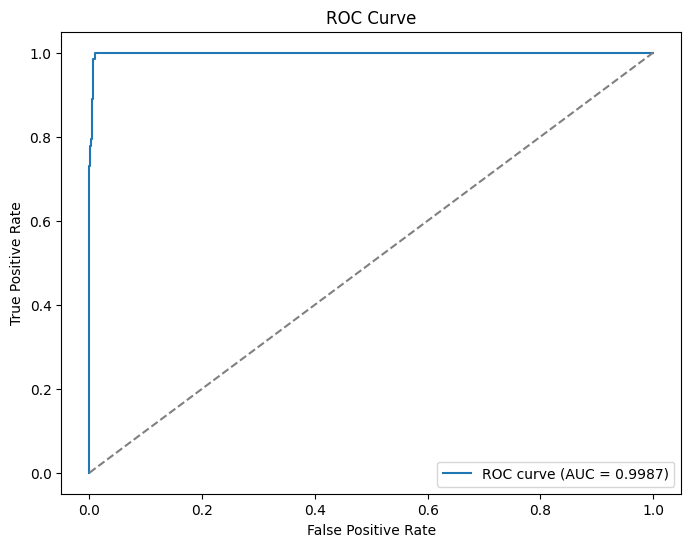

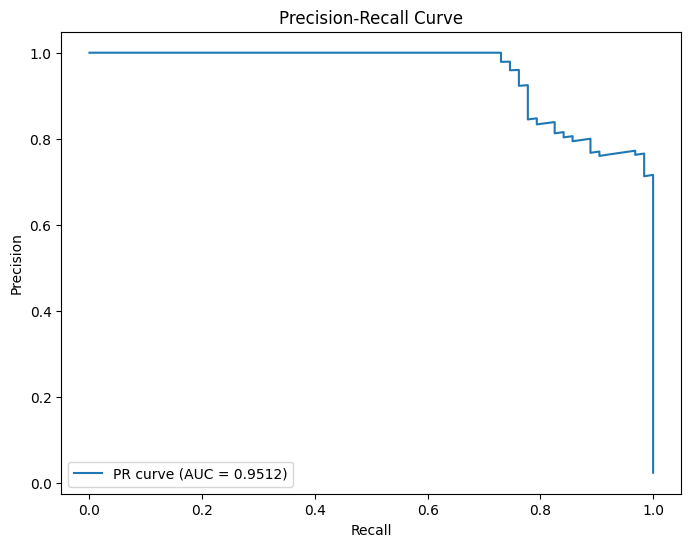

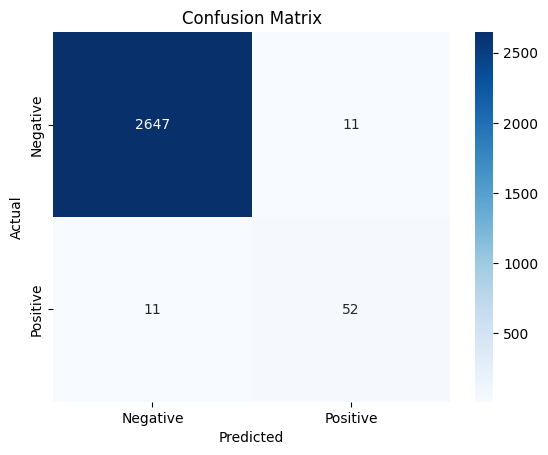

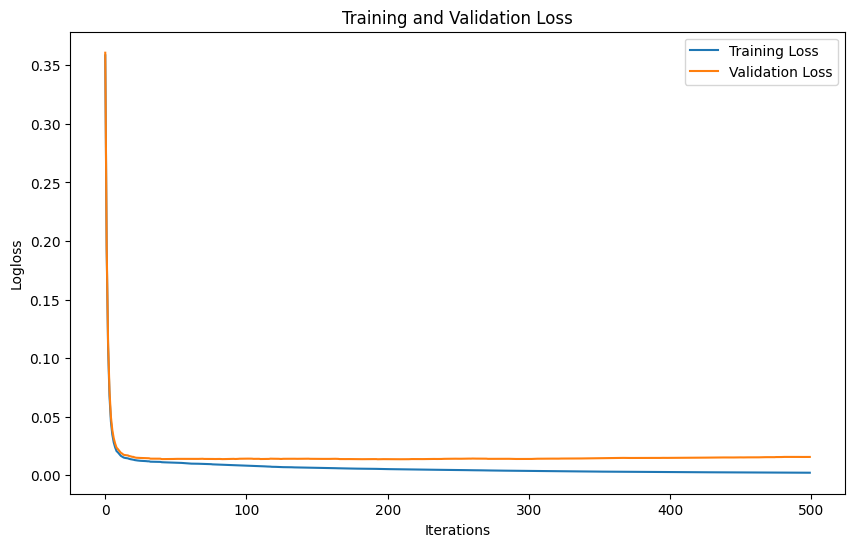

In [148]:


# Предположим, что df_cleaned_reduced_vif уже загружен и столбец 'ym:s:goalsID' существует

# Преобразуем целевой столбец в бинарный формат
df_cleaned_reduced_vif['target'] = df_cleaned_reduced_vif['ym:s:goalsID'].apply(lambda x: 1 if '291725831' in x else 0)

# Разделяем данные на признаки и цель
# X = df_cleaned_reduced_vif.drop(columns=['target','ym:s:goalsPrice','ym:s:endURL','ym:s:pageViews','ym:s:offlineCallTag','ym:s:goalsID'])

X = df_cleaned_reduced_vif.drop(columns=['target','ym:s:goalsID'])
y = df_cleaned_reduced_vif['target']
# Перемешиваем таргет
# y_shuffled = np.random.permutation(y)

# Находим все столбцы с типом object (строковые данные)
cat_features = X.select_dtypes(include=['object']).columns.tolist()
X[cat_features] = X[cat_features].fillna("missing")
# Разделяем данные на тренировочную и тестовую выборки с учётом стратификации
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Инициализируем модель CatBoost
model = CatBoostClassifier(iterations=500, depth=4, learning_rate=0.1, loss_function='Logloss', cat_features=cat_features, random_seed=42)

# Обучаем модель
model.fit(X_train, y_train, eval_set=(X_test, y_test), verbose=100)

# Прогнозы
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Оценка модели

# ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

# PR AUC
pr_auc = average_precision_score(y_test, y_pred_proba)
print(f"PR AUC: {pr_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

# Построение ROC кривой
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

# Построение Precision-Recall кривой
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR curve (AUC = {pr_auc:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='lower left')
plt.show()

# Построение confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Построение графика обучения
plt.figure(figsize=(10, 6))
plt.plot(model.get_evals_result()['learn']['Logloss'], label='Training Loss')
plt.plot(model.get_evals_result()['validation']['Logloss'], label='Validation Loss')
plt.xlabel('Iterations')
plt.ylabel('Logloss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


In [149]:
# Получаем важность признаков
feature_importances = model.get_feature_importance()

# Получаем имена признаков
feature_names = X.columns

# Создаем DataFrame с признаками и их важностью
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Сортируем по важности и выводим 20 лучших признаков
top_20_features = feature_importance_df.sort_values(by='Importance', ascending=False).head(20)

print(top_20_features)


                                         Feature  Importance
92                  ym:s:offlineCallTalkDuration   20.378906
12                                   ym:s:endURL   11.627330
28                                ym:s:pageViews   10.234562
16                            ym:s:goalsDateTime    6.957862
108                ym:s:offlineCallMissed_length    6.439354
102                       ym:s:goalsOrder_length    4.497461
33                                 ym:s:startURL    3.860321
17                               ym:s:goalsOrder    3.411611
103                       ym:s:goalsPrice_length    3.341496
91                           ym:s:offlineCallTag    2.973831
106       ym:s:offlineCallFirstTimeCaller_length    2.031135
80                             ym:s:screenFormat    1.896498
90                        ym:s:offlineCallMissed    1.573687
83                             ym:s:screenHeight    1.460562
18                               ym:s:goalsPrice    1.403903
19                      

In [9]:
X_1 = X.copy()
X_1['target']= y.values
X_1[['target','ym:s:goalsPrice','ym:s:endURL','ym:s:pageViews']].to_excel('1.xlsx')

In [151]:
import category_encoders as ce
import pandas as pd

# # Преобразуем категориальные признаки с помощью CatBoostEncoder
# X = df.drop(columns=['ym:s:goalsID', 'target'])
# y = df['target']

# Указываем, какие признаки являются категориальными
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Инициализируем CatBoostEncoder
encoder = ce.CatBoostEncoder(cols=cat_features)

# Применяем CatBoostEncoder для категориальных признаков
X_encoded = encoder.fit_transform(X, y)
# Заменяем NaN значения на медиану для предотвращения ошибки
X_encoded = X_encoded.fillna(X_encoded.median())

# Убираем признаки с нулевой дисперсией (константные столбцы)
X_encoded = X_encoded.loc[:, X_encoded.nunique() > 1]


# Вычисляем корреляцию для всех признаков
correlation = X_encoded.corrwith(y)

# Выводим признаки с высокой корреляцией с таргетом (например, корреляция больше 0.5)
high_correlation = correlation[abs(correlation) > 0.5]
print(high_correlation)


ym:s:endURL                        0.810762
ym:s:goalsDateTime                 0.597024
ym:s:goalsOrder                    0.626060
ym:s:goalsPrice                    0.596059
ym:s:goalsSerialNumber             0.630173
ym:s:startURL                      0.731727
ym:s:offlineCallFirstTimeCaller    0.591915
ym:s:offlineCallHoldDuration       0.591915
ym:s:offlineCallMissed             0.591915
ym:s:offlineCallTag                0.591915
ym:s:offlineCallTalkDuration       0.591915
ym:s:offlineCallURL                0.591915
dtype: float64


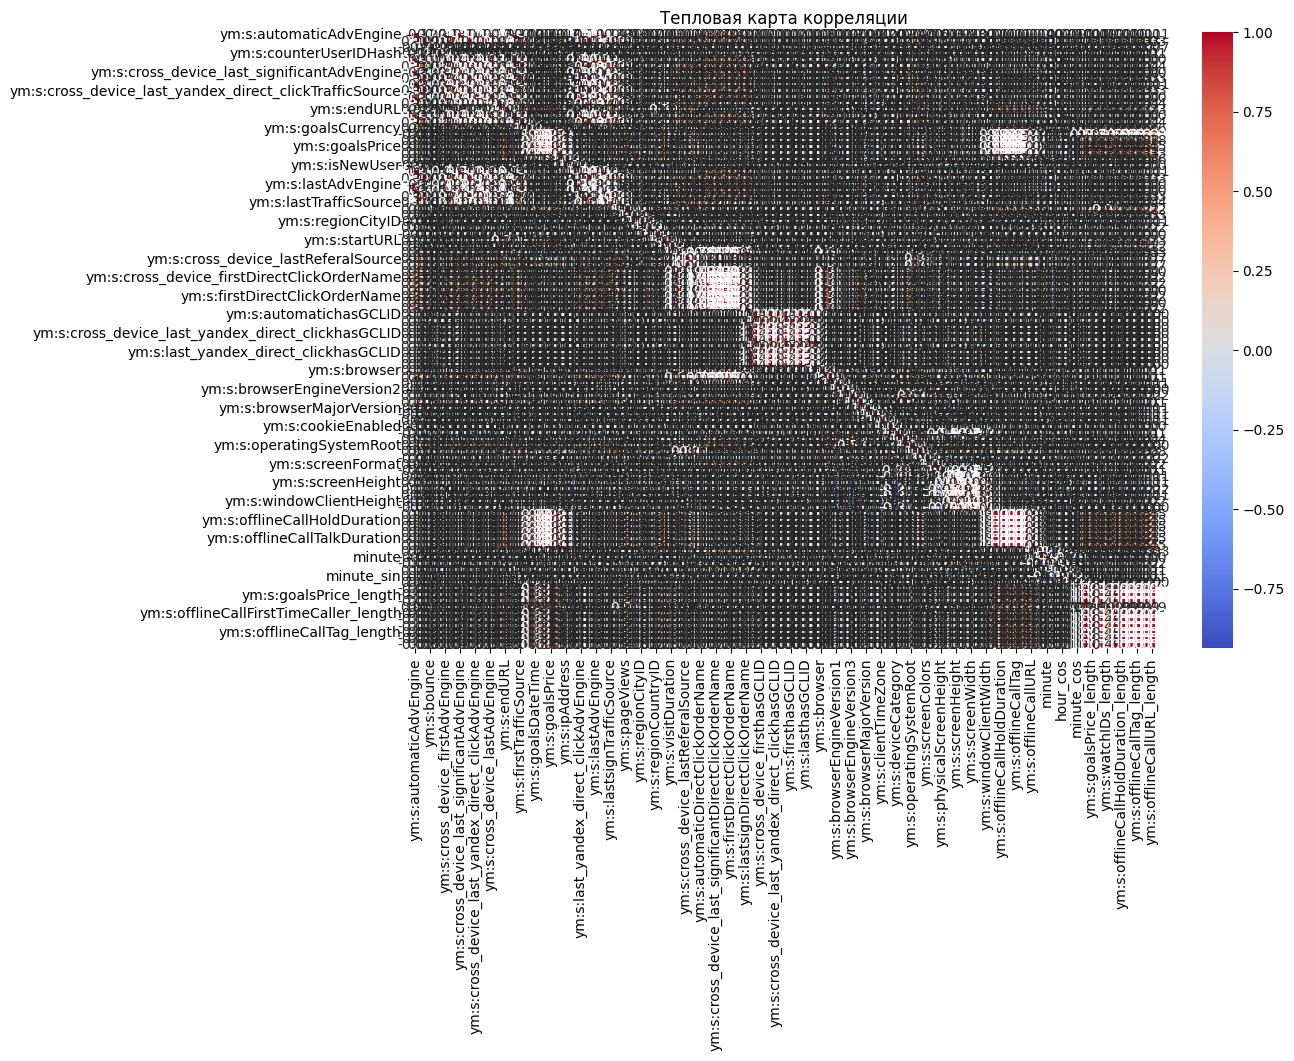

In [152]:
# Создаем тепловую карту
plt.figure(figsize=(12, 8))  # Устанавливаем размер графика
sns.heatmap(X_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

# Показываем тепловую карту
plt.title('Тепловая карта корреляции')
plt.show()

In [153]:
# Вычисляем корреляцию Спирмена
correlation_spearman = X_encoded.corrwith(y, method='spearman')

# Выводим признаки с высокой корреляцией с таргетом (например, корреляция больше 0.5)
high_correlation_spearman = correlation_spearman[abs(correlation_spearman) > 0.1]
print(high_correlation_spearman)

ym:s:endURL                               0.221006
ym:s:goalsDateTime                        0.249397
ym:s:goalsOrder                           0.251621
ym:s:goalsPrice                           0.250443
ym:s:goalsSerialNumber                    0.252340
ym:s:pageViews                            0.147838
ym:s:startURL                             0.211261
ym:s:visitDuration                        0.117414
ym:s:offlineCallFirstTimeCaller           0.250179
ym:s:offlineCallHoldDuration              0.250179
ym:s:offlineCallMissed                    0.250179
ym:s:offlineCallTag                       0.250179
ym:s:offlineCallTalkDuration              0.250179
ym:s:offlineCallURL                       0.250179
ym:s:goalsOrder_length                    0.592773
ym:s:goalsPrice_length                    0.592773
ym:s:goalsSerialNumber_length             0.592773
ym:s:watchIDs_length                      0.136872
ym:s:offlineCallFirstTimeCaller_length    0.592773
ym:s:offlineCallHoldDuration_le

In [154]:
# Вычисляем корреляцию Кендалла
correlation_kendall = X_encoded.corrwith(y, method='kendall')

# Выводим признаки с высокой корреляцией с таргетом (например, корреляция больше 0.9)
high_correlation_kendall = correlation_kendall[abs(correlation_kendall) > 0.1]
print(high_correlation_kendall)

ym:s:endURL                               0.182070
ym:s:goalsDateTime                        0.204005
ym:s:goalsOrder                           0.205464
ym:s:goalsPrice                           0.204494
ym:s:goalsSerialNumber                    0.206048
ym:s:pageViews                            0.142317
ym:s:startURL                             0.174200
ym:s:visitDuration                        0.101858
ym:s:offlineCallFirstTimeCaller           0.204278
ym:s:offlineCallHoldDuration              0.204278
ym:s:offlineCallMissed                    0.204278
ym:s:offlineCallTag                       0.204278
ym:s:offlineCallTalkDuration              0.204278
ym:s:offlineCallURL                       0.204278
ym:s:goalsOrder_length                    0.587473
ym:s:goalsPrice_length                    0.587473
ym:s:goalsSerialNumber_length             0.587473
ym:s:watchIDs_length                      0.126875
ym:s:offlineCallFirstTimeCaller_length    0.587473
ym:s:offlineCallHoldDuration_le

In [20]:
from sklearn.feature_selection import mutual_info_classif

# Рассчитываем взаимную информацию для признаков относительно целевой переменной
mutual_info = mutual_info_classif(X_encoded, y)

# Создаем DataFrame с результатами
mutual_info_df = pd.DataFrame({
    'feature': X_encoded.columns,
    'mutual_info': mutual_info
})

# Сортируем по взаимной информации
mutual_info_df = mutual_info_df.sort_values(by='mutual_info', ascending=False)

# Выводим 10 наиболее важных признаков
print(mutual_info_df.head(10))


KeyboardInterrupt: 